# Anti-Money Laundering (AML) Detection System Using Machine Learning
### CA2 Project – Data Science | MSc IT – Part I

**Dataset:** Synthetic Anti-Money Laundering Dataset (SAML-D)  
**Target:** `Is_laundering`

This notebook follows the CA2 workflow: dataset selection, problem definition, preprocessing, EDA, visualization, machine learning, evaluation, insights and conclusion.

> **Important:** Download `SAML-D.csv` from the dataset source before running the notebook. If the full file is too large for the computer, set `SAMPLE_SIZE` below to a manageable value and document the sample used.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Problem Statement

To develop a machine learning-based system that analyzes financial transaction information and classifies transactions as potentially suspicious or non-suspicious using relevant transaction features.

## 2. Objectives

1. Understand and analyze financial transaction data.
2. Preprocess the dataset for analysis and machine learning.
3. Perform Exploratory Data Analysis (EDA).
4. Create at least five meaningful visualizations, including one interactive Plotly chart.
5. Develop a classification model for identifying potentially suspicious transactions.
6. Evaluate the model using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.
7. Derive data-supported findings and conclusions.

In [2]:
# 3. Import Libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# 4. Load Dataset
DATA_PATH = "SAML-D.csv"
SAMPLE_SIZE = 300000   # Change to None to use the full dataset if your computer can handle it.

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "SAML-D.csv not found. Download it from the Kaggle dataset source and place it "
        "in the same folder as this notebook."
    )

if SAMPLE_SIZE:
    df = pd.read_csv(DATA_PATH, nrows=SAMPLE_SIZE)
else:
    df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded.
Shape: (9984, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2.769355e+09,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8.401255e+09,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0.0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4.404767e+09,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0.0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9.600420e+09,11895.00,UK pounds,UK pounds,UK,UK,ACH,0.0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3.803337e+09,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits


In [4]:
# 5. Basic Dataset Information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Unique Values": [df[c].nunique() for c in df.columns]
}))

Rows: 9984
Columns: 12


,Column,Data Type,Missing Values,Unique Values
0,Time,object,0,8024
1,Date,object,0,1
2,Sender_account,int64,0,5413
3,Receiver_account,float64,1,5772
4,Amount,float64,1,9941
5,Payment_currency,object,1,13
6,Received_currency,object,1,13
7,Sender_bank_location,object,1,17
8,Receiver_bank_location,object,1,18
9,Payment_type,object,1,7


In [5]:
# 6. Duplicates and Descriptive Statistics
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,9984,8024,11:36:55,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,9984,1,2022-10-07,9984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sender_account,9984.0,NaN,NaN,NaN,5161009975.248498,2830506041.590616,9734.0,2757260976.75,5195441820.0,7669236826.0,9995637068.0
Receiver_account,9983.0,NaN,NaN,NaN,5014239986.770209,2795178569.390923,716444.0,2534644942.0,5147353792.0,7263703253.5,9999812305.0
Amount,9983.0,NaN,NaN,NaN,8360.908585,24980.714077,9.11,1960.325,5821.66,9806.58,998453.63
Payment_currency,9983,13,UK pounds,9682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Received_currency,9983,13,UK pounds,9045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sender_bank_location,9983,17,UK,9762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Receiver_bank_location,9983,18,UK,9134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_type,9983,7,Credit card,2064,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 7. Missing Values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Remove rows missing the target, if any.
if "Is_laundering" not in df.columns:
    raise KeyError("Expected target column 'Is_laundering' was not found.")

df = df.dropna(subset=["Is_laundering"]).copy()
print("Shape after target cleanup:", df.shape)

,0
Receiver_account,1
Received_currency,1
Payment_currency,1
Amount,1
Receiver_bank_location,1
Payment_type,1
Is_laundering,1
Sender_bank_location,1
Laundering_type,1


Shape after target cleanup: (9983, 12)


## 8. Feature Engineering

The deployed application uses `Amount_Risk` and `Payment_Risk`. The notebook recreates these features where the corresponding source columns are available.

In [7]:
# Feature engineering aligned with the deployed app
if "Amount" in df.columns:
    def amount_risk(x):
        if x <= 1000: return 0
        if x <= 10000: return 1
        if x <= 50000: return 2
        return 3
    df["Amount_Risk"] = df["Amount"].apply(amount_risk)

if "Payment_type" in df.columns:
    df["Payment_Risk"] = df["Payment_type"].astype(str).str.lower().isin(
        ["cash", "cheque"]
    ).astype(int)

display(df.head())

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Amount_Risk,Payment_Risk
0,10:35:19,2022-10-07,8724731955,2.769355e+09,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits,1,0
1,10:35:20,2022-10-07,1491989064,8.401255e+09,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0.0,Normal_Fan_Out,1,0
2,10:35:20,2022-10-07,287305149,4.404767e+09,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0.0,Normal_Small_Fan_Out,2,1
3,10:35:21,2022-10-07,5376652437,9.600420e+09,11895.00,UK pounds,UK pounds,UK,UK,ACH,0.0,Normal_Fan_In,2,0
4,10:35:21,2022-10-07,9614186178,3.803337e+09,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0.0,Normal_Cash_Deposits,0,0


## 9. Exploratory Data Analysis

,Count
Is_laundering,
0.0,9970
1.0,13


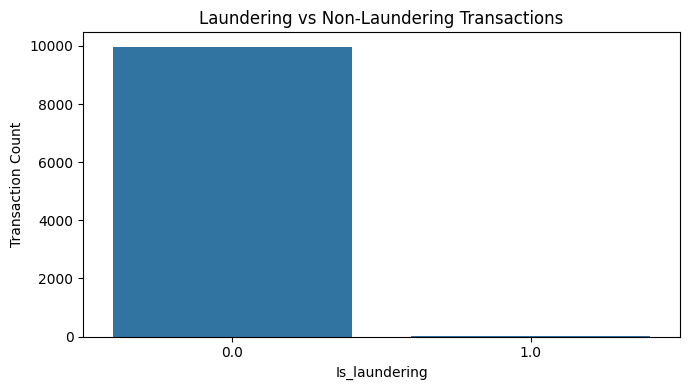

In [8]:
# Target distribution
target_counts = df["Is_laundering"].value_counts(dropna=False).sort_index()
display(target_counts.to_frame("Count"))

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Is_laundering")
plt.title("Laundering vs Non-Laundering Transactions")
plt.xlabel("Is_laundering")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

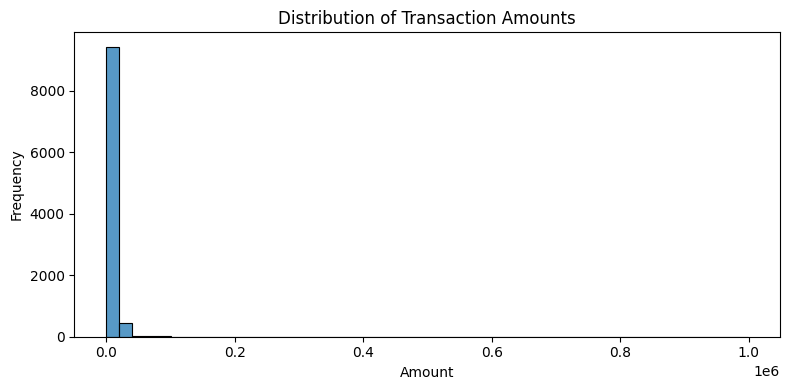

In [9]:
# Visualization 1: Transaction amount distribution
if "Amount" in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df["Amount"].clip(lower=0), bins=50)
    plt.title("Distribution of Transaction Amounts")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

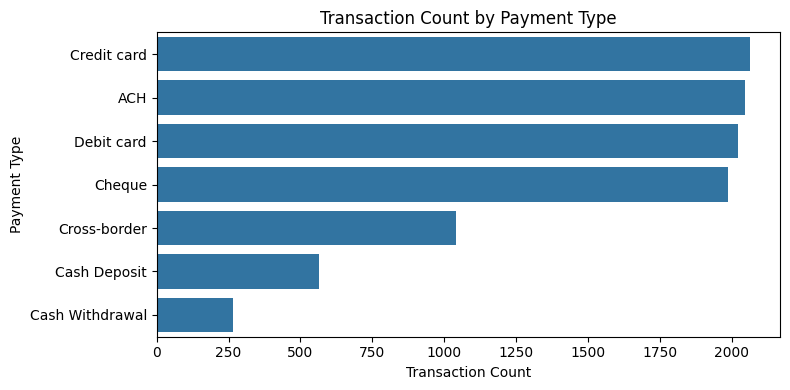

In [10]:
# Visualization 2: Payment type
if "Payment_type" in df.columns:
    plt.figure(figsize=(8,4))
    order = df["Payment_type"].value_counts().index
    sns.countplot(data=df, y="Payment_type", order=order)
    plt.title("Transaction Count by Payment Type")
    plt.xlabel("Transaction Count")
    plt.ylabel("Payment Type")
    plt.tight_layout()
    plt.show()

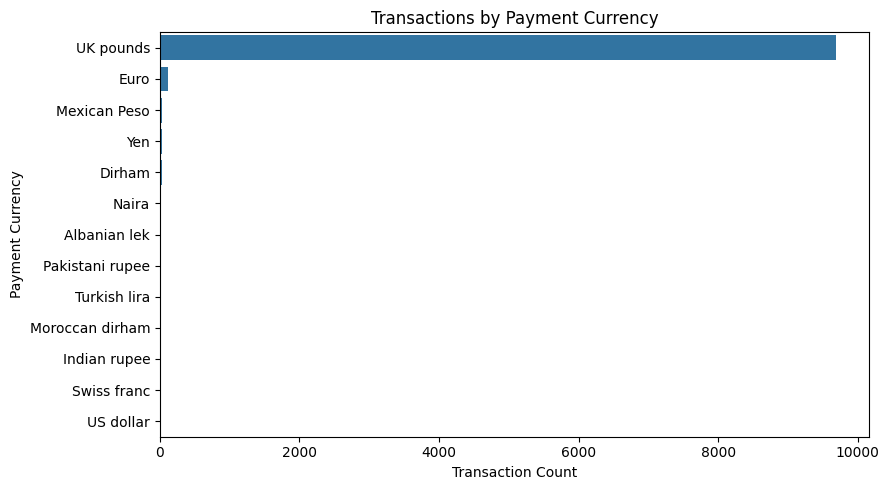

In [11]:
# Visualization 3: Payment currency
if "Payment_currency" in df.columns:
    top_currency = df["Payment_currency"].value_counts().head(15).index
    plt.figure(figsize=(9,5))
    sns.countplot(data=df[df["Payment_currency"].isin(top_currency)],
                  y="Payment_currency",
                  order=top_currency)
    plt.title("Transactions by Payment Currency")
    plt.xlabel("Transaction Count")
    plt.ylabel("Payment Currency")
    plt.tight_layout()
    plt.show()

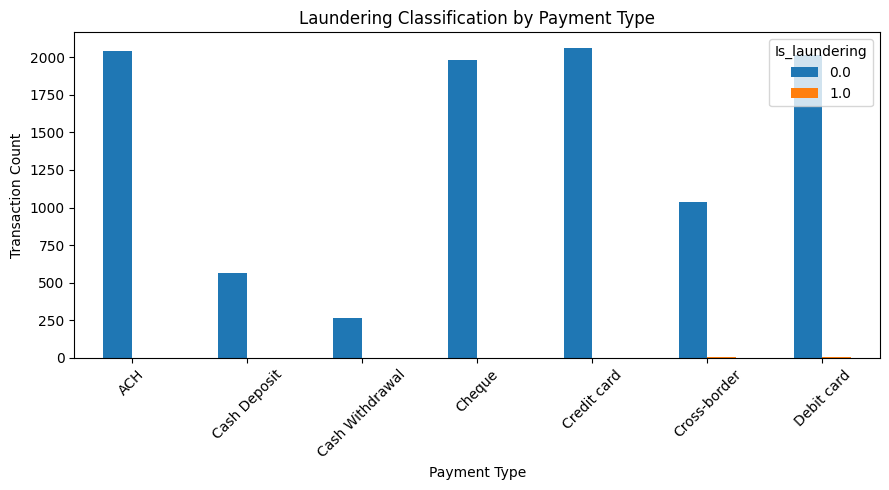

In [12]:
# Visualization 4: Laundering by payment type
if {"Payment_type", "Is_laundering"}.issubset(df.columns):
    ctab = pd.crosstab(df["Payment_type"], df["Is_laundering"])
    ctab.plot(kind="bar", figsize=(9,5))
    plt.title("Laundering Classification by Payment Type")
    plt.xlabel("Payment Type")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

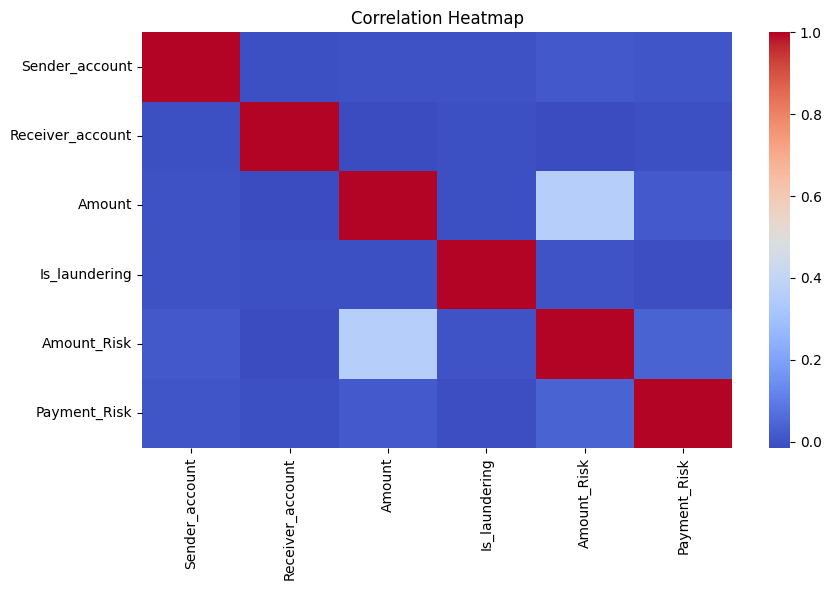

In [13]:
# Visualization 5: Correlation heatmap for numeric columns
num_df = df.select_dtypes(include=np.number)
if num_df.shape[1] >= 2:
    plt.figure(figsize=(9,6))
    sns.heatmap(num_df.corr(), annot=False, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [14]:
# Visualization 6: Interactive Plotly chart
if {"Payment_type", "Is_laundering"}.issubset(df.columns):
    plot_df = (
        df.groupby(["Payment_type", "Is_laundering"])
          .size()
          .reset_index(name="Transaction_Count")
    )
    fig = px.bar(
        plot_df,
        x="Payment_type",
        y="Transaction_Count",
        color="Is_laundering",
        barmode="group",
        title="Interactive Transaction Count by Payment Type and Laundering Status"
    )
    fig.show()

## 10. Machine Learning

A Random Forest Classifier is used for the binary classification problem. The model is trained using selected transaction features. Categorical features are one-hot encoded and numerical features are passed through unchanged.

In [15]:
# Select practical features available in the dataset
candidate_features = [
    "Amount", "Payment_currency", "Received_currency",
    "Sender_bank_location", "Receiver_bank_location",
    "Payment_type", "Amount_Risk", "Payment_Risk"
]
features = [c for c in candidate_features if c in df.columns]

X = df[features].copy()
y = df["Is_laundering"].astype(int)

print("Features used:", features)
print("Target:", "Is_laundering")
print("Class distribution:")
display(y.value_counts(normalize=True).rename("Proportion").to_frame())

Features used: ['Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Amount_Risk', 'Payment_Risk']
Target: Is_laundering
Class distribution:


,Proportion
Is_laundering,
0,0.998698
1,0.001302


In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [17]:
# Model evaluation
y_pred = model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0)
}
display(pd.DataFrame([metrics]))

print(classification_report(y_test, y_pred, zero_division=0))

,Accuracy,Precision,Recall,F1-Score
0,0.997496,0.0,0.0,0.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1994
           1       0.00      0.00      0.00         3

    accuracy                           1.00      1997
   macro avg       0.50      0.50      0.50      1997
weighted avg       1.00      1.00      1.00      1997



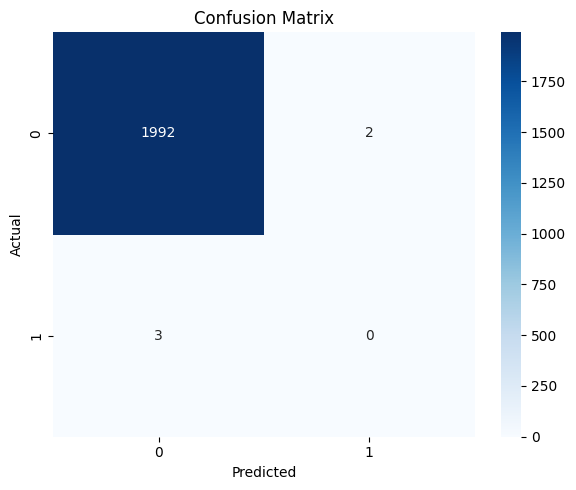

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 11. Findings and Insights

Run the notebook and use the actual displayed values to complete at least five findings. Do not invent values.

1. The target distribution shows: **[INSERT ACTUAL OBSERVATION]**.
2. The transaction amount distribution shows: **[INSERT ACTUAL OBSERVATION]**.
3. The payment type analysis shows: **[INSERT ACTUAL OBSERVATION]**.
4. The currency/location analysis shows: **[INSERT ACTUAL OBSERVATION]**.
5. The Random Forest model achieved: **[INSERT ACTUAL METRICS]**.

## 12. Conclusion

The project demonstrates a complete Data Science workflow for Anti-Money Laundering transaction monitoring, including preprocessing, EDA, visualization, classification and evaluation. The model provides an analytical approach for classifying transaction records based on selected transaction characteristics.

## 13. Future Scope

- Compare additional machine learning algorithms.
- Apply hyperparameter tuning.
- Address class imbalance using suitable techniques.
- Add probability-based risk scores.
- Improve model explainability.
- Integrate real-time transaction monitoring.
- Deploy the solution as an enterprise AML monitoring system.